# L7 — Feature Descriptors: Follow-Along Examples
**MCS 3950 Computer Vision · UPEI · Fall 2026**

This notebook accompanies **Lecture 7**. L6 gave us *where* the features are — a
position and a scale. This lecture gives each one a **description** so the same
point can be found again in another image. Same three PEI clips as AL2 and L6, so
every number here matches the slides.

| Section | Topic |
|---------|-------|
| 0 | Get the imagery, and a test pair with a known answer |
| 1 | Why not just compare raw pixels? |
| 2 | Orientation assignment |
| 3 | The SIFT descriptor, from scratch |
| 4 | Illumination: normalise, clip, renormalise |
| 5 | SIFT on the 1968 clip |
| 6 | Binary descriptors — BRIEF from scratch |
| 7 | ORB — oriented FAST, rotated BRIEF |
| 8 | Distance metrics |
| 9 | Matching strategies and the ratio test |
| 10 | SIFT vs ORB, head to head |
| 11 | Across a decade — 1958 vs 1968 |
| ✏️ | **Try at home** |

> **Not submitted or graded.**

In [1]:
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
GOLD, RED, TEAL, GREEN, NAVY = "#C8962C", "#B82828", "#1A7A8A", "#2E7D50", "#1A3A5C"

def show(images, titles, cmap='gray', vmin=0, vmax=255, figw=15):
    # Show a row of images.
    fig, axes = plt.subplots(1, len(images), figsize=(figw, 4))
    if len(images) == 1:
        axes = [axes]
    for ax, im, t in zip(axes, images, titles):
        ax.imshow(im, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(t, fontsize=11)
        ax.axis('off')
    plt.tight_layout(); plt.show()

print(f"OpenCV {cv2.__version__}  (SIFT has been in the main package since 4.4)")

OpenCV 4.14.0  (SIFT has been in the main package since 4.4)


---
## 0 · Get the imagery

Same download cell as AL2, L5 and L6.

Aerial imagery already present — skipping download.
1935: 800x800 px   mean 133.3   std 40.7
1958: 800x800 px   mean 154.1   std 41.1
1968: 800x800 px   mean 161.8   std 28.3


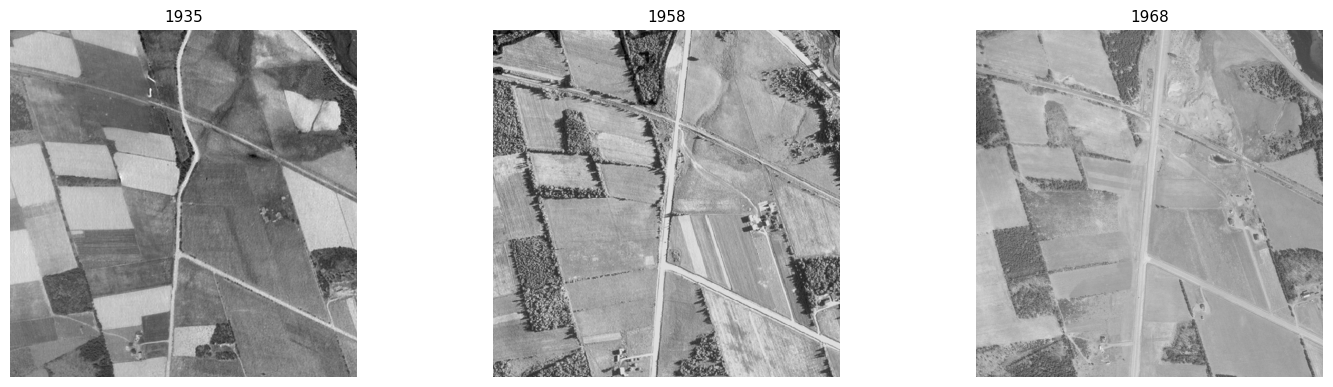

In [ ]:
# ── Get the aerial imagery ──────────────────────────────────────────
# Downloads three scanned PEI aerial photographs (~3 MB). Safe to re-run.
import io, os, urllib.request, zipfile

DATA_URL = ("https://raw.githubusercontent.com/andrewgodbout/"
            "MCS-3950-F26/main/Notebooks/data/AL2.zip")
NEEDED = ["pei_1935.png", "pei_1958.png", "pei_1968.png"]

if all(os.path.exists(f) for f in NEEDED):
    print("Aerial imagery already present — skipping download.")
else:
    with urllib.request.urlopen(DATA_URL, timeout=60) as resp:
        blob = resp.read()
    with zipfile.ZipFile(io.BytesIO(blob)) as z:
        z.extractall(".")
    print(f"  {len(blob)/1e6:.1f} MB downloaded and extracted")

# resample all three onto a common 800 x 800 grid at 1 m/px, as in AL2
RES = {1935: 0.5, 1958: 1.1593543264609192, 1968: 0.5}
YEARS = [1935, 1958, 1968]

def to_grid(img, src_res, target=1.0):
    s = src_res / target
    wh = (int(round(img.shape[1]*s)), int(round(img.shape[0]*s)))
    interp = cv2.INTER_AREA if s < 1 else cv2.INTER_CUBIC
    return cv2.resize(img, wh, interpolation=interp)

aerial = {y: to_grid(cv2.imread(f"pei_{y}.png", cv2.IMREAD_GRAYSCALE), RES[y])
          for y in YEARS}
side = min(min(a.shape) for a in aerial.values())
aerial = {y: a[:side, :side] for y, a in aerial.items()}

for y in YEARS:
    a = aerial[y]
    print(f"{y}: {a.shape[1]}x{a.shape[0]} px   mean {a.mean():5.1f}   std {a.std():4.1f}")

show([aerial[y] for y in YEARS], [str(y) for y in YEARS])

### 0.1 — A test pair where we *know* the answer

To say a match is right or wrong we need ground truth. The cleanest way is to make
the second image ourselves: rotate, shrink, change the exposure and add grain to the
1968 clip. Because we built the warp, we know exactly where every pixel went, so a
match is **correct** if the matched keypoint lies within 3 px of where the first
keypoint should have landed.

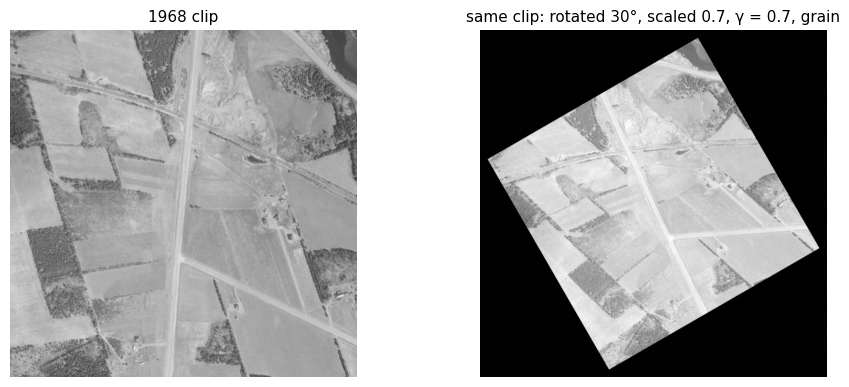

H =
 [[  0.606   0.35   17.513]
 [ -0.35    0.606 297.513]
 [  0.      0.      1.   ]]


In [ ]:
img = aerial[1968]
h, w = img.shape

def make_pair(img, angle=30, scale=0.7, gain=1.1, gamma=0.7, noise=4, seed=0):
    # Rotate + scale about the centre, then a non-linear exposure change and grain.
    # Returns the new image, the 3x3 matrix H that maps img -> new, and a valid-pixel mask.
    A = cv2.getRotationMatrix2D((w/2, h/2), angle, scale)
    H = np.vstack([A, [0, 0, 1]])
    out = cv2.warpAffine(img, A, (w, h), flags=cv2.INTER_LINEAR, borderValue=0)
    f = out.astype(np.float64) / 255
    rng = np.random.default_rng(seed)
    f = gain * f**gamma * 255 + rng.normal(0, noise, f.shape)
    mask = cv2.warpAffine(np.full_like(img, 255), A, (w, h))
    return np.clip(f, 0, 255).astype(np.uint8), H, mask

def project(pts, H):
    # Apply a 3x3 transform to an (N, 2) array of points.
    p = np.c_[pts, np.ones(len(pts))] @ H.T
    return p[:, :2] / p[:, 2:]

TOL = 3   # px

def is_correct(kp1, kp2, matches, H, tol=TOL):
    # Boolean per match: does kp2 sit where H says kp1 should have gone?
    p1 = project(np.float32([kp1[m.queryIdx].pt for m in matches]), H)
    p2 = np.float32([kp2[m.trainIdx].pt for m in matches])
    return np.linalg.norm(p1 - p2, axis=1) < tol

img2, H, mask2 = make_pair(img)
show([img, img2], ["1968 clip", "same clip: rotated 30°, scaled 0.7, γ = 0.7, grain"], figw=10)
print("H =\n", np.round(H, 3))

---
## 1 · Why not just compare raw pixels?

The obvious descriptor is the patch itself: cut a 16×16 window around each keypoint,
subtract its mean and divide by its standard deviation (so brightness does not matter),
and match by Euclidean distance. That is normalised cross-correlation from L3 wearing a
different hat.

Rotate the clip in 5° steps and count how often the nearest neighbour is the right
answer. We only score keypoints that *have* a partner in the rotated image, so the
detector's repeatability does not muddy the result.

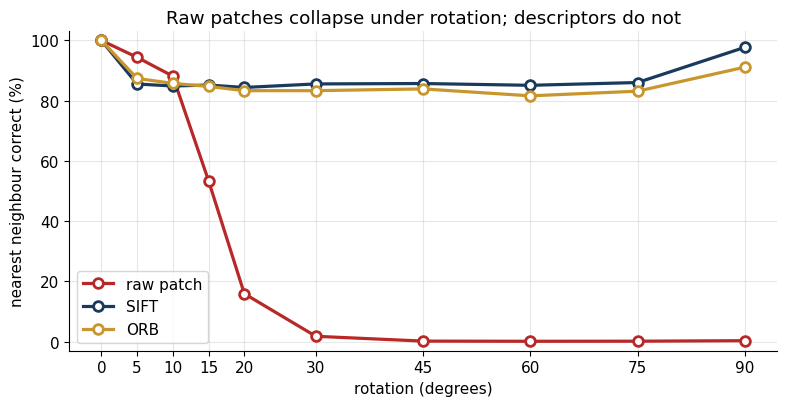

 angle   raw   SIFT   ORB
    0°  100.0  100.0  100.0
    5°   94.4   85.5   87.4
   10°   88.1   84.9   85.7
   15°   53.4   85.2   84.7
   20°   15.9   84.4   83.3
   30°    1.8   85.5   83.3
   45°    0.2   85.7   83.9
   60°    0.1   85.1   81.6
   75°    0.2   86.0   83.1
   90°    0.3   97.7   91.1


In [ ]:
sift = cv2.SIFT_create()
orb  = cv2.ORB_create(nfeatures=3000)

def raw_patches(im, kps, r=8):
    # 16x16 mean/std-normalised patches, axis-aligned. Drops keypoints near the border.
    out, keep = [], []
    for i, k in enumerate(kps):
        x, y = map(int, map(round, k.pt))
        if r <= x < im.shape[1]-r and r <= y < im.shape[0]-r:
            p = im[y-r:y+r, x-r:x+r].astype(np.float32).ravel()
            out.append((p - p.mean()) / (p.std() + 1e-6)); keep.append(i)
    return np.array(out, np.float32), [kps[i] for i in keep]

def nn_accuracy(kp1, d1, kp2, d2, H, norm):
    # Fraction of keypoints with a true partner whose nearest neighbour IS that partner.
    pts2 = np.float32([k.pt for k in kp2])
    proj = project(np.float32([k.pt for k in kp1]), H)
    D = np.linalg.norm(proj[:, None] - pts2[None], axis=2)
    has_partner = D.min(1) < TOL
    m = cv2.BFMatcher(norm).match(d1, d2)
    right = np.array([D[x.queryIdx, x.trainIdx] < TOL for x in m])
    q = np.array([x.queryIdx for x in m])
    return right[has_partner[q]].mean()

ANGLES = [0, 5, 10, 15, 20, 30, 45, 60, 75, 90]
acc = {"raw patch": [], "SIFT": [], "ORB": []}
k1s, d1s = sift.detectAndCompute(img, None)
k1o, d1o = orb.detectAndCompute(img, None)
P1, k1p = raw_patches(img, k1s)

for a in ANGLES:
    im2, Ha, m2 = make_pair(img, angle=a, scale=1.0, gain=1.0, gamma=1.0, noise=0)
    k2s, d2s = sift.detectAndCompute(im2, m2)
    P2, k2p = raw_patches(im2, k2s)
    k2o, d2o = orb.detectAndCompute(im2, m2)
    acc["raw patch"].append(nn_accuracy(k1p, P1, k2p, P2, Ha, cv2.NORM_L2))
    acc["SIFT"].append(nn_accuracy(k1s, d1s, k2s, d2s, Ha, cv2.NORM_L2))
    acc["ORB"].append(nn_accuracy(k1o, d1o, k2o, d2o, Ha, cv2.NORM_HAMMING))

plt.figure(figsize=(8, 4.2))
for (name, v), col in zip(acc.items(), [RED, NAVY, GOLD]):
    plt.plot(ANGLES, 100*np.array(v), 'o-', color=col, lw=2.3, ms=7, mfc='white', mew=2, label=name)
plt.xlabel("rotation (degrees)"); plt.ylabel("nearest neighbour correct (%)")
plt.xticks(ANGLES); plt.ylim(-3, 103); plt.grid(alpha=0.3); plt.legend()
plt.title("Raw patches collapse under rotation; descriptors do not")
plt.tight_layout(); plt.show()

print(" angle   raw   SIFT   ORB")
for i, a in enumerate(ANGLES):
    print(f"  {a:3d}°  {100*acc['raw patch'][i]:5.1f}  {100*acc['SIFT'][i]:5.1f}  {100*acc['ORB'][i]:5.1f}")

Two things to notice. The raw patch is *better* than SIFT for tiny rotations — it has
thrown nothing away — and then falls off a cliff between 10° and 20°. And 90° is
special for everyone: rotating by exactly 90° just shuffles pixels, so nothing is
resampled and nothing is lost.

A descriptor is a deliberate trade: give up some of what the raw patch knows, in
exchange for not caring about the things that change between photographs.

---
## 2 · Orientation assignment

To be rotation invariant, SIFT measures the patch *relative to its own dominant
direction*. Around each keypoint of scale $\sigma$:

1. compute gradient magnitude and direction on the image blurred to $\sigma$;
2. weight each magnitude by a Gaussian of width $1.5\sigma$;
3. vote into a **36-bin** histogram (10° per bin);
4. smooth the histogram (OpenCV uses a $[1\,4\,6\,4\,1]/16$ kernel, wrapping round at 360°);
5. the peak is the keypoint's orientation $\theta$. Any other peak above **80%** of
   the maximum spawns a *second keypoint* at the same place with that orientation.

The 80% test is applied to the **smoothed** histogram. A single spiky bin can tower over
its neighbours in the raw votes and still be only a modest peak once smoothed — compare
the grey bars with the navy curve below.

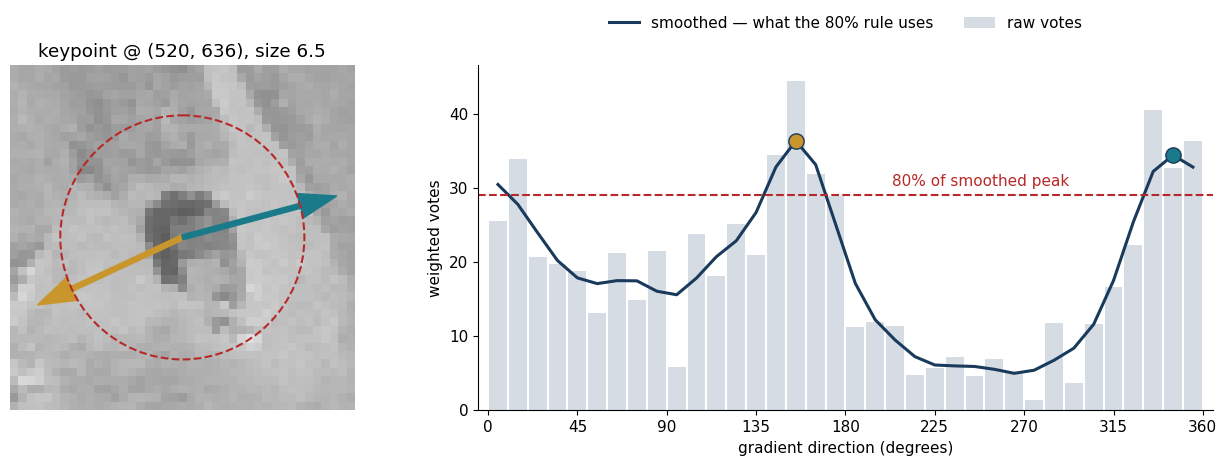

dominant orientation ≈ 155°, second peak ≈ 345°
second peak / first:  raw 74%   smoothed 95%
OpenCV made 2 keypoints here, at [157, 343] degrees


In [ ]:
def orientation_hist(img, kp, nbins=36):
    # Gaussian-weighted histogram of gradient directions around a keypoint (Lowe 2004, sec. 5).
    sig = 1.5 * kp.size / 2                      # OpenCV's kp.size is 2*sigma
    r = int(round(3 * sig))
    x, y = map(int, map(round, kp.pt))
    if not (r+2 <= x < img.shape[1]-r-2 and r+2 <= y < img.shape[0]-r-2):
        return None
    P = img[y-r-1:y+r+2, x-r-1:x+r+2].astype(np.float64)
    P = cv2.GaussianBlur(P, (0, 0), kp.size/2, borderType=cv2.BORDER_REFLECT)
    gy, gx = np.gradient(P)
    gx, gy = gx[1:-1, 1:-1], gy[1:-1, 1:-1]
    mag = np.hypot(gx, gy)
    ang = np.degrees(np.arctan2(gy, gx)) % 360   # image coords: y points down
    yy, xx = np.mgrid[-r:r+1, -r:r+1]
    wgt = np.exp(-(xx**2 + yy**2) / (2 * sig**2))
    hist, _ = np.histogram(ang, bins=nbins, range=(0, 360), weights=mag * wgt)
    return hist

kps = sift.detect(img, None)
strong = sorted(kps, key=lambda k: -k.response)

# pick a strong, medium-sized keypoint with a clear second peak to illustrate the 80% rule
def peaks(hist):
    # Smooth the (circular) histogram with OpenCV's [1 4 6 4 1]/16 kernel, then keep
    # every local maximum at or above 80% of the SMOOTHED maximum.
    hs = np.convolve(np.r_[hist[-2:], hist, hist[:2]], np.array([1, 4, 6, 4, 1])/16, 'valid')
    return [i for i in range(len(hs)) if hs[i] >= 0.8*hs.max()
            and hs[i] > hs[i-1] and hs[i] > hs[(i+1) % len(hs)]], hs

def opencv_angles_at(k):
    return sorted({round(q.angle) for q in kps
                   if np.hypot(q.pt[0]-k.pt[0], q.pt[1]-k.pt[1]) < 0.5})

def near(a, b, tol=10):
    return abs((a - b + 180) % 360 - 180) < tol

demo = None
for k in strong:                     # a keypoint where OpenCV also made two orientations
    hst = orientation_hist(img, k)
    if hst is None or not (6 < k.size < 20): continue
    p, _ = peaks(hst); cv = opencv_angles_at(k)
    if len(p) == 2 and len(cv) == 2 and all(any(near((i+0.5)*10, a) for a in cv) for i in p):
        demo = k; break
hist = orientation_hist(img, demo)
pk, hs = peaks(hist)

r = int(3 * 1.5 * demo.size / 2) + 6
x, y = map(int, map(round, demo.pt))
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1, 1.6]})
ax[0].imshow(img[y-r:y+r+1, x-r:x+r+1], cmap='gray', vmin=0, vmax=255)
for i, col in zip(pk, [GOLD, TEAL]):
    t = np.radians((i + 0.5) * 10)
    L = 3 * 1.5 * demo.size / 2
    ax[0].arrow(r, r, L*np.cos(t), L*np.sin(t), color=col, width=0.6, head_width=3)
ax[0].add_patch(plt.Circle((r, r), 3*1.5*demo.size/2, fill=False, ec=RED, lw=1.5, ls='--'))
ax[0].set_title(f"keypoint @ ({x}, {y}), size {demo.size:.1f}"); ax[0].axis('off')
centres = np.arange(36)*10 + 5
ax[1].bar(centres, hist, width=9, color="#D5DCE4", label="raw votes")
ax[1].plot(centres, hs, '-', color=NAVY, lw=2.2, label="smoothed — what the 80% rule uses")
for i, col in zip(pk, [GOLD, TEAL]):
    ax[1].plot(centres[i], hs[i], 'o', ms=11, color=col, mec=NAVY, zorder=5)
ax[1].axhline(0.8*hs.max(), color=RED, ls='--', lw=1.5)
ax[1].text(248, 0.8*hs.max() + 1.2, "80% of smoothed peak", color=RED, ha='center')
ax[1].set_xlabel("gradient direction (degrees)"); ax[1].set_ylabel("weighted votes")
ax[1].set_xticks(range(0, 361, 45)); ax[1].legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.06), ncol=2)
ax[1].set_xlim(-5, 365)
plt.tight_layout(); plt.show()

print(f"dominant orientation ≈ {(pk[0]+0.5)*10:.0f}°, second peak ≈ {(pk[1]+0.5)*10:.0f}°")
print(f"second peak / first:  raw {hist[pk[1]]/hist[pk[0]]:.0%}   smoothed {hs[pk[1]]/hs[pk[0]]:.0%}")
print(f"OpenCV made {len(opencv_angles_at(demo))} keypoints here, at {opencv_angles_at(demo)} degrees")

In [ ]:
# How often does our 25-line version agree with OpenCV's?
agree = []
for k in strong[:300]:
    hst = orientation_hist(img, k)
    if hst is None: continue
    p, _ = peaks(hst)
    a = (np.array(p) + 0.5) * 10
    agree.append(np.min(np.abs((a - k.angle + 180) % 360 - 180)) < 10)
print(f"our peaks within 10° of OpenCV's angle: {100*np.mean(agree):.0f}% of the 300 strongest keypoints")
print("(OpenCV also fits a parabola to each peak to get a sub-bin angle.)")

locs = np.unique(np.round([k.pt for k in kps], 2), axis=0)
print(f"\n{len(kps):,} SIFT keypoints at {len(locs):,} distinct locations —")
print(f"{len(kps)-len(locs):,} ({100*(len(kps)-len(locs))/len(kps):.0f}%) are second orientations from the 80% rule.")

our peaks within 10° of OpenCV's angle: 78% of the 300 strongest keypoints
(OpenCV also fits a parabola to each peak to get a sub-bin angle.)

3,580 SIFT keypoints at 2,917 distinct locations —
663 (19%) are second orientations from the 80% rule.


---
## 3 · The SIFT descriptor, from scratch

With a position, a scale and an orientation, we can cut out a patch that is the same
patch in any photograph. Then:

* resample a **16×16** grid, rotated to $\theta$ and scaled to the keypoint;
  each grid step is $6 \cdot \text{size}/16$ pixels, so the window covers 6× the keypoint size;
* compute gradients and weight the magnitudes by a Gaussian ($\sigma$ = half the window);
* split into **4×4 cells**, each voting into an **8-bin** orientation histogram;
* $4 \times 4 \times 8 = \mathbf{128}$ numbers.

Real SIFT also spreads each vote over neighbouring cells and bins (trilinear
interpolation) so a one-pixel shift does not flip a vote. We skip that here.

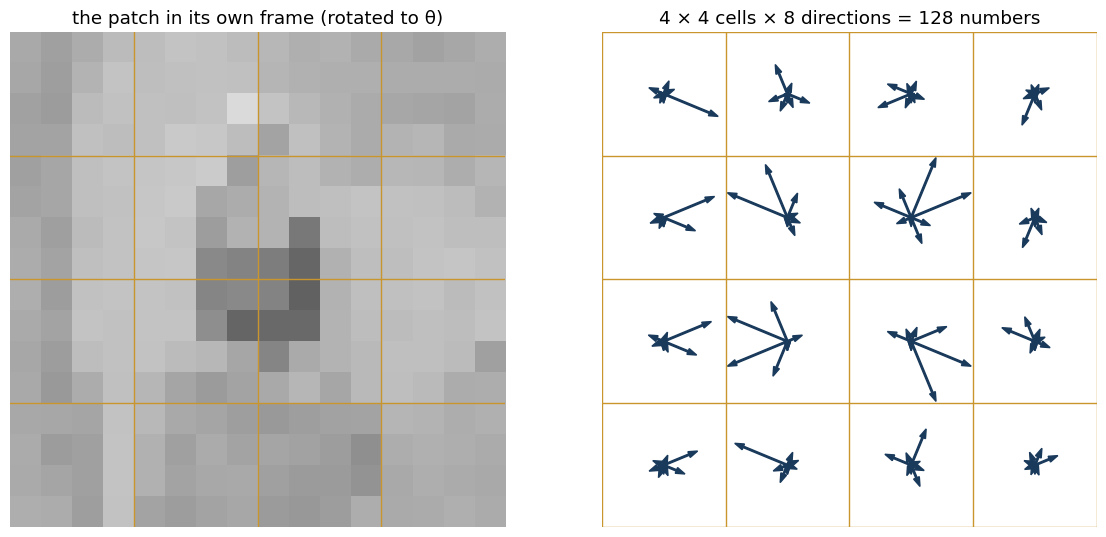

In [ ]:
def my_sift(img, kps):
    # A plain-NumPy SIFT descriptor: 4x4 cells x 8 bins, normalise-clip-renormalise.
    f = img.astype(np.float64)
    out = []
    for kp in kps:
        s = 6 * kp.size / 16                     # image px per grid step
        th = np.radians(kp.angle)
        c, sn = np.cos(th) * s, np.sin(th) * s
        # affine map from grid coords (0..17) to image coords, rotated by theta
        M = np.array([[c, -sn, kp.pt[0]], [sn, c, kp.pt[1]]])
        M[:, 2] -= M[:, :2] @ [9, 9]
        P = cv2.warpAffine(f, M, (18, 18), flags=cv2.INTER_LINEAR | cv2.WARP_INVERSE_MAP,
                           borderMode=cv2.BORDER_REFLECT)
        gy, gx = np.gradient(P)
        gx, gy = gx[1:-1, 1:-1], gy[1:-1, 1:-1]  # 16 x 16
        mag = np.hypot(gx, gy)
        ang = np.arctan2(gy, gx) % (2*np.pi)     # already relative to theta
        yy, xx = np.mgrid[-8:8, -8:8] + 0.5
        mag = mag * np.exp(-(xx**2 + yy**2) / (2 * 8**2))
        b = (ang / (2*np.pi) * 8).astype(int) % 8
        d = np.zeros((4, 4, 8))
        np.add.at(d, (np.arange(16)[:, None]//4, np.arange(16)[None, :]//4, b), mag)
        d = d.ravel()
        d /= np.linalg.norm(d) + 1e-12           # 1. unit length
        d = np.minimum(d, 0.2)                   # 2. clip big gradients
        d /= np.linalg.norm(d) + 1e-12           # 3. renormalise
        out.append(d)
    return np.float32(out)

d_demo = my_sift(img, [demo])[0].reshape(4, 4, 8)

fig, ax = plt.subplots(1, 2, figsize=(12, 5.5))
# the rotated, scaled patch the descriptor actually sees
s = 6*demo.size/16; th = np.radians(demo.angle)
M = np.array([[np.cos(th)*s, -np.sin(th)*s, demo.pt[0]], [np.sin(th)*s, np.cos(th)*s, demo.pt[1]]])
M[:, 2] -= M[:, :2] @ [8, 8]
patch = cv2.warpAffine(img, M, (16, 16), flags=cv2.INTER_LINEAR | cv2.WARP_INVERSE_MAP)
ax[0].imshow(patch, cmap='gray', vmin=0, vmax=255, extent=[0, 16, 16, 0])
for g in (4, 8, 12):
    ax[0].axhline(g, color=GOLD, lw=1); ax[0].axvline(g, color=GOLD, lw=1)
ax[0].set_title("the patch in its own frame (rotated to θ)"); ax[0].axis('off')
# 4x4 grid of 8-arrow "stars"
ax[1].set_xlim(0, 4); ax[1].set_ylim(4, 0); ax[1].set_aspect('equal')
for i in range(4):
    for j in range(4):
        for k in range(8):
            t = (k + 0.5) * np.pi / 4
            L = 0.45 * d_demo[i, j, k] / d_demo.max()
            ax[1].arrow(j+0.5, i+0.5, L*np.cos(t), L*np.sin(t), color=NAVY, width=0.012, head_width=0.05)
for g in range(5):
    ax[1].axhline(g, color=GOLD, lw=1); ax[1].axvline(g, color=GOLD, lw=1)
ax[1].set_title("4 × 4 cells × 8 directions = 128 numbers"); ax[1].axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# Does our version actually match? Test it on the rotated / rescaled / re-exposed pair.
k1, d1 = sift.detectAndCompute(img, None)
k2, d2 = sift.detectAndCompute(img2, mask2)

t0 = time.perf_counter()
m1, m2 = my_sift(img, k1), my_sift(img2, k2)
t_mine = time.perf_counter() - t0

def ratio_matches(a, b, norm, ratio=0.8):
    knn = cv2.BFMatcher(norm).knnMatch(a, b, k=2)
    return [m for m, n in knn if m.distance < ratio * n.distance]

for name, (a, b) in {"our NumPy SIFT": (m1, m2), "OpenCV SIFT": (d1, d2)}.items():
    good = ratio_matches(a, b, cv2.NORM_L2)
    ok = is_correct(k1, k2, good, H)
    print(f"{name:15}  {len(good):4d} matches kept   {100*ok.mean():5.1f}% correct   ({ok.sum()} right)")
print(f"\n(same keypoints for both; ours took {t_mine:.1f} s to describe {len(k1)+len(k2):,} of them)")

our NumPy SIFT    797 matches kept    99.5% correct   (793 right)
OpenCV SIFT       931 matches kept    94.8% correct   (883 right)

(same keypoints for both; ours took 0.7 s to describe 5,153 of them)


Thirty lines of NumPy get you most of the way. OpenCV keeps more matches — most likely
because trilinear interpolation makes its descriptor less brittle to small misalignments
(Try-at-home **C** tests that) — while the matches ours does keep are slightly *cleaner*. That is the whole idea:
nothing in SIFT's descriptor is magic.

### 3.1 — The grid follows the blob, not the pixels

The 16 × 16 grid is measured in units of the keypoint's own **σ** — the scale at which
DoG found it in L6 — not in image pixels. OpenCV reports `kp.size` $= 2\sigma$; each of
the 4 cells is $3\sigma$ wide, so the whole window is $12\sigma = 6 \times$ `kp.size`.

* A speck found at $\sigma \approx 1.4$ px gets a 17 px window, sampled about once per pixel.
* A woodlot edge found at $\sigma \approx 10$ px gets a 124 px window, sampled every 7.8 px.

Either way the result is exactly 16 × 16 samples. Photograph the same scene at twice the
resolution and DoG reports twice the σ, the window doubles, and the 16 × 16 samples come
out the same — that is the scale invariance.

Real SIFT reads those samples from the image **blurred to the keypoint's σ** (its level in
the DoG pyramid), so samples 8 px apart do not alias — L3 and L6 again. `sample_grid`
below does that; `my_sift` above skipped it.

In [ ]:
def sample_grid(im, kp, upright=False, n=16):
    # Read the image on the keypoint's own n x n grid: centred on the keypoint, spanning
    # 12 sigma (= 6 * kp.size), tilted by theta. Like SIFT, sample the image blurred to the
    # keypoint's own sigma, so widely spaced samples do not alias (L3, L6).
    sigma = kp.size / 2                          # OpenCV's kp.size is 2 * sigma
    blur = cv2.GaussianBlur(im.astype(np.float64), (0, 0), sigma)
    th = 0.0 if upright else np.radians(kp.angle)
    s = 12 * sigma / n                           # spacing between samples, in image px
    M = np.array([[np.cos(th)*s, -np.sin(th)*s, kp.pt[0]],
                  [np.sin(th)*s,  np.cos(th)*s, kp.pt[1]]])
    M[:, 2] -= M[:, :2] @ [(n-1)/2, (n-1)/2]
    return cv2.warpAffine(blur, M, (n, n), flags=cv2.INTER_LINEAR | cv2.WARP_INVERSE_MAP)

def draw_grid(ax, kp, col, ox=0, oy=0, n=16, lw=2.0):
    # Draw the tilted window, its 4x4 cells, the n x n sample points and the theta arrow.
    th = np.radians(kp.angle); h = 6 * kp.size / 2
    R = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
    to_img = lambda a, b: R @ np.array([a, b]) * h + np.array(kp.pt) - [ox, oy]
    for t in np.linspace(-1, 1, 5):
        for a0, b0, a1, b1 in [(t, -1, t, 1), (-1, t, 1, t)]:
            p0, p1 = to_img(a0, b0), to_img(a1, b1)
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]], '-', color=col, lw=lw if abs(t) == 1 else lw/2)
    u = (np.arange(n) - (n-1)/2) / (n/2)
    pts = np.array([to_img(a, b) for b in u for a in u])
    ax.plot(pts[:, 0], pts[:, 1], '.', color=col, ms=2.5)
    tip = to_img(1, 0)
    ax.annotate('', xy=tip, xytext=to_img(0, 0), arrowprops=dict(arrowstyle='-|>', color=col, lw=lw))

def ncc(a, b):
    a = (a - a.mean()) / (a.std() + 1e-9); b = (b - b.mean()) / (b.std() + 1e-9)
    return float((a * b).mean())

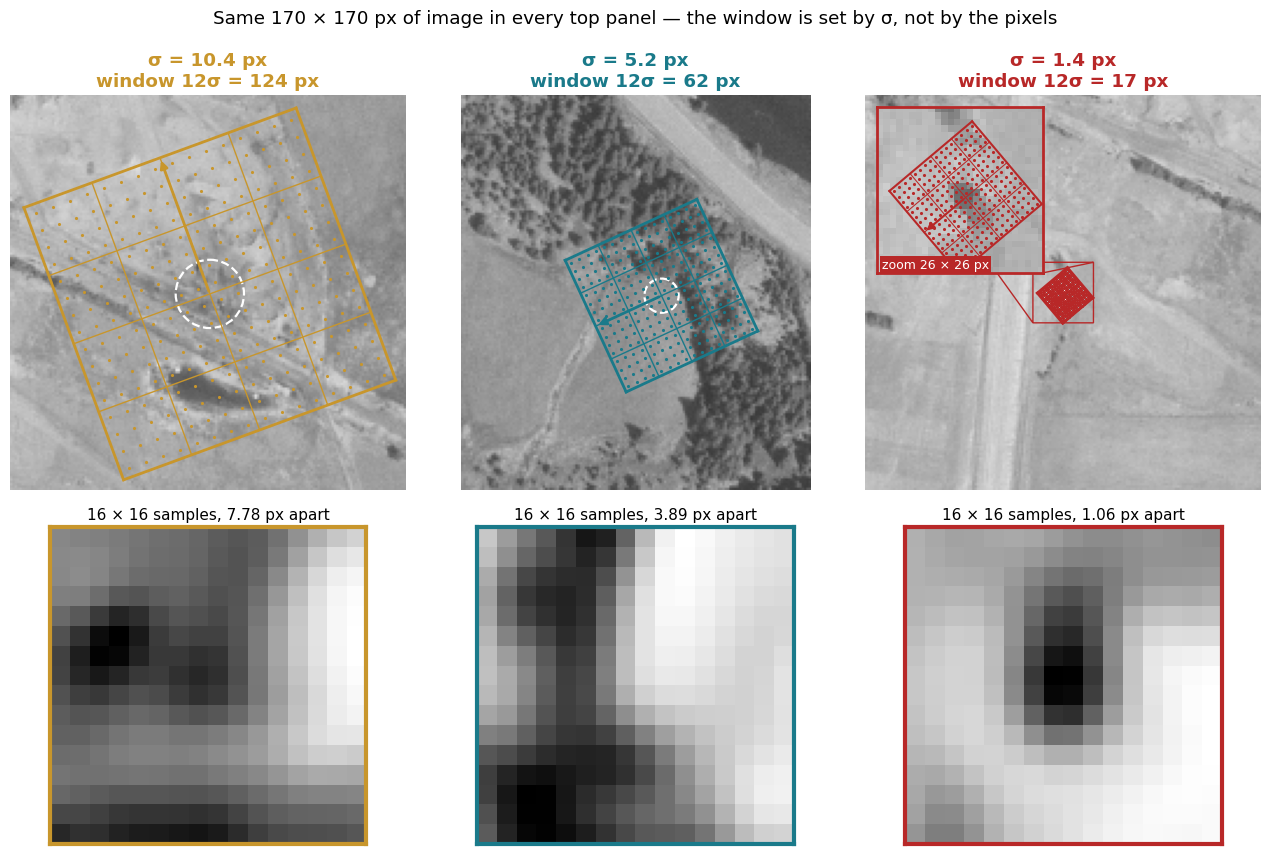

white dashed circle = the blob DoG found (radius √2σ); the window is 12σ wide, about 4.2x the blob's diameter — the blob plus its surroundings.


In [ ]:
def nearest_kp(kps, x, y, angle):
    return min(kps, key=lambda k: np.hypot(k.pt[0]-x, k.pt[1]-y) + abs((k.angle-angle+180) % 360 - 180)/100)

SCALE_DEMO = [nearest_kp(kps, 564.3, 257.1, 250),      # large: woodlot edge
              nearest_kp(kps, 735.6, 174.8, 155),      # medium
              nearest_kp(kps, 429.3, 291.7, 140)]      # small: a speck
COLS, CROP = [GOLD, TEAL, RED], 170                    # every top panel shows the same 170 x 170 px

fig, ax = plt.subplots(2, 3, figsize=(13, 8.6), gridspec_kw={"height_ratios": [1, 0.8]})
for j, (k, col) in enumerate(zip(SCALE_DEMO, COLS)):
    sigma = k.size / 2
    x0, y0 = int(k.pt[0]) - CROP//2, int(k.pt[1]) - CROP//2
    ax[0, j].imshow(img[y0:y0+CROP, x0:x0+CROP], cmap='gray', vmin=0, vmax=255)
    draw_grid(ax[0, j], k, col, x0, y0)
    ax[0, j].add_patch(plt.Circle((k.pt[0]-x0, k.pt[1]-y0), np.sqrt(2)*sigma, fill=False, ec='white', lw=1.6, ls='--'))
    ax[0, j].set_title(f"σ = {sigma:.1f} px\nwindow 12σ = {12*sigma:.0f} px", color=col, fontweight='bold')
    ax[0, j].axis('off')
    if j == 2:                                         # magnify the tiny one
        Z = 13
        ins = ax[0, j].inset_axes([0.03, 0.55, 0.42, 0.42])
        zx, zy = int(k.pt[0]) - Z - x0, int(k.pt[1]) - Z - y0     # in crop coordinates
        ins.imshow(img[y0+zy:y0+zy+2*Z, x0+zx:x0+zx+2*Z], cmap='gray', vmin=0, vmax=255,
                   interpolation='nearest', extent=[zx-0.5, zx+2*Z-0.5, zy+2*Z-0.5, zy-0.5])
        draw_grid(ins, k, col, x0, y0, lw=1.5)
        ins.set_xlim(zx-0.5, zx+2*Z-0.5); ins.set_ylim(zy+2*Z-0.5, zy-0.5)
        ins.set_xticks([]); ins.set_yticks([])
        for s_ in ins.spines.values(): s_.set_visible(True); s_.set_edgecolor(col); s_.set_linewidth(2)
        ins.text(0.03, 0.03, "zoom 26 × 26 px", transform=ins.transAxes, color='white', fontsize=9,
                 bbox=dict(fc=col, ec='none', pad=1.5))
        ax[0, j].indicate_inset_zoom(ins, edgecolor=col, alpha=1)
    P = sample_grid(img, k)
    ax[1, j].imshow(P, cmap='gray', vmin=P.min(), vmax=P.max())
    ax[1, j].set_title(f"16 × 16 samples, {12*sigma/16:.2f} px apart", fontsize=11)
    for s_ in ax[1, j].spines.values(): s_.set_visible(True); s_.set_edgecolor(col); s_.set_linewidth(3)
    ax[1, j].set_xticks([]); ax[1, j].set_yticks([])
plt.suptitle("Same 170 × 170 px of image in every top panel — the window is set by σ, not by the pixels", y=0.99)
plt.tight_layout(); plt.show()
print("white dashed circle = the blob DoG found (radius √2σ); the window is 12σ wide, "
      f"about {12/(2*np.sqrt(2)):.1f}x the blob's diameter — the blob plus its surroundings.")

### 3.2 — Same scene, same patch

Now the payoff. Take one correctly matched keypoint from the test pair. The copy was
rotated 30° and shrunk to 0.7×, and SIFT noticed both: its σ and θ changed by exactly
those amounts. So its tilted grid covers the same piece of ground, and the 16 × 16 samples
agree. An upright square of the same size, not turned by θ, does not.

1968 clip : size 11.61  theta  358.5°   window  69.6 px
test copy : size  8.07  theta  328.4°   window  48.4 px
ratio of sizes 0.70 (the copy was scaled by 0.7); change in theta -30.1° (the copy was rotated 30°)


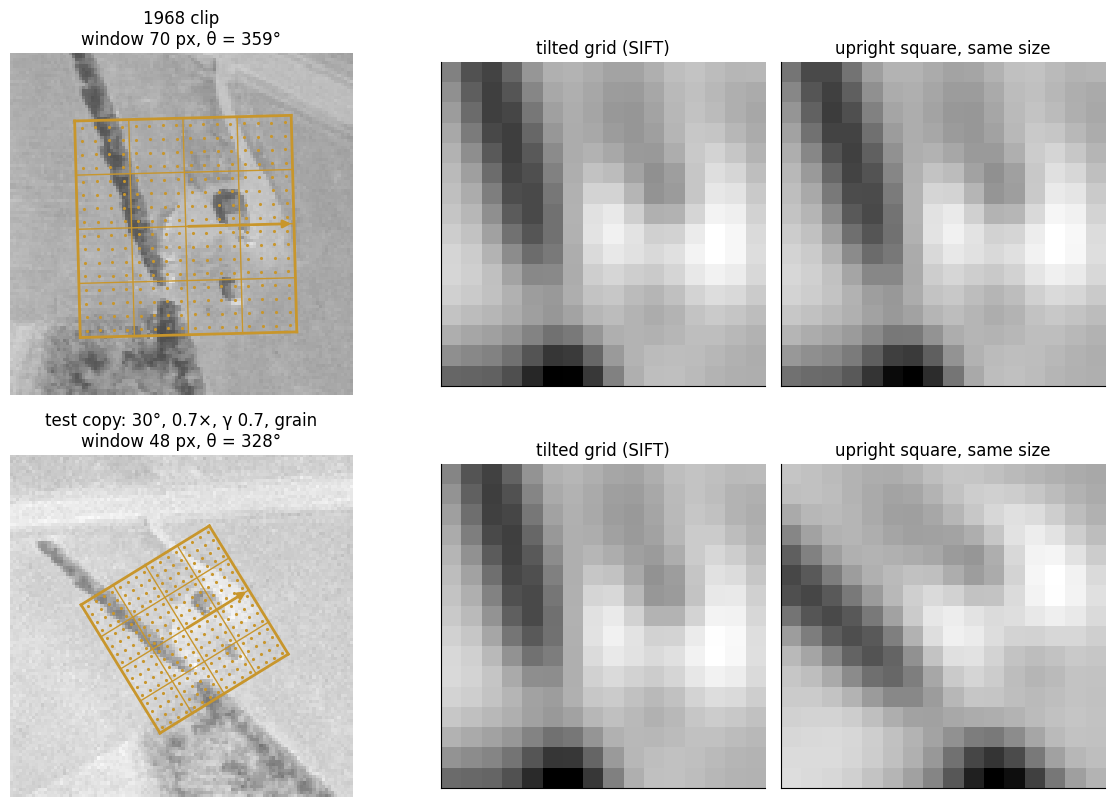

this keypoint:  NCC between the two tilted patches 1.00,  between the two upright squares 0.28


all 883 correct SIFT matches:  median NCC tilted 0.99,  upright 0.63


In [ ]:
ka = nearest_kp(k1, 507.0, 642.2, 358.5)               # 1968 clip
kb = nearest_kp(k2, 549.7, 509.6, 328.4)               # same ground spot in the test copy
print(f"1968 clip : size {ka.size:5.2f}  theta {ka.angle:6.1f}°   window {6*ka.size:5.1f} px")
print(f"test copy : size {kb.size:5.2f}  theta {kb.angle:6.1f}°   window {6*kb.size:5.1f} px")
print(f"ratio of sizes {kb.size/ka.size:.2f} (the copy was scaled by 0.7); "
      f"change in theta {(kb.angle-ka.angle+180)%360-180:+.1f}° (the copy was rotated 30°)")

C2 = 110
fig, ax = plt.subplots(2, 3, figsize=(12, 8.2), gridspec_kw={"width_ratios": [1.5, 1, 1]})
for i, (im, k, lab) in enumerate([(img, ka, "1968 clip"), (img2, kb, "test copy: 30°, 0.7×, γ 0.7, grain")]):
    x0, y0 = int(k.pt[0]) - C2//2, int(k.pt[1]) - C2//2
    ax[i, 0].imshow(im[y0:y0+C2, x0:x0+C2], cmap='gray', vmin=0, vmax=255)
    draw_grid(ax[i, 0], k, GOLD, x0, y0)
    ax[i, 0].set_title(f"{lab}\nwindow {6*k.size:.0f} px, θ = {k.angle:.0f}°", fontsize=12); ax[i, 0].axis('off')
    for j, (up, t) in enumerate([(False, "tilted grid (SIFT)"), (True, "upright square, same size")]):
        P = sample_grid(im, k, upright=up)
        ax[i, j+1].imshow(P, cmap='gray', vmin=P.min(), vmax=P.max())
        ax[i, j+1].set_title(t, fontsize=12); ax[i, j+1].set_xticks([]); ax[i, j+1].set_yticks([])
plt.tight_layout(); plt.show()

t_ab = ncc(sample_grid(img, ka), sample_grid(img2, kb))
u_ab = ncc(sample_grid(img, ka, True), sample_grid(img2, kb, True))
print(f"this keypoint:  NCC between the two tilted patches {t_ab:.2f},  between the two upright squares {u_ab:.2f}")

good = ratio_matches(d1, d2, cv2.NORM_L2)
ok = is_correct(k1, k2, good, H)
T, U = [], []
for m in [g for g, o in zip(good, ok) if o]:
    a, b = k1[m.queryIdx], k2[m.trainIdx]
    T.append(ncc(sample_grid(img, a), sample_grid(img2, b)))
    U.append(ncc(sample_grid(img, a, True), sample_grid(img2, b, True)))
print(f"all {len(T)} correct SIFT matches:  median NCC tilted {np.median(T):.2f},  upright {np.median(U):.2f}")

---
## 4 · Illumination: normalise, clip, renormalise

Two different kinds of lighting change:

* **Linear**, $I' = aI + b$. Gradients kill $b$; normalising to unit length kills $a$. Exact.
* **Non-linear** — a different film, a different exposure curve, glare. Some gradients get
  stretched far more than others. Lowe clips every entry at **0.2** and renormalises, so a
  handful of very strong edges cannot dominate the vector.

First, describe the *same keypoints* before and after each change and measure how far the
descriptor moved.

In [ ]:
def describe(img, kps, clip=True):
    # my_sift with the clip step switchable.
    f = img.astype(np.float64); out = []
    for kp in kps:
        s = 6 * kp.size / 16; th = np.radians(kp.angle)
        M = np.array([[np.cos(th)*s, -np.sin(th)*s, kp.pt[0]], [np.sin(th)*s, np.cos(th)*s, kp.pt[1]]])
        M[:, 2] -= M[:, :2] @ [9, 9]
        P = cv2.warpAffine(f, M, (18, 18), flags=cv2.INTER_LINEAR | cv2.WARP_INVERSE_MAP,
                           borderMode=cv2.BORDER_REFLECT)
        gy, gx = np.gradient(P); gx, gy = gx[1:-1, 1:-1], gy[1:-1, 1:-1]
        yy, xx = np.mgrid[-8:8, -8:8] + 0.5
        mag = np.hypot(gx, gy) * np.exp(-(xx**2 + yy**2) / 128)
        b = (np.arctan2(gy, gx) % (2*np.pi) / (2*np.pi) * 8).astype(int) % 8
        d = np.zeros((4, 4, 8))
        np.add.at(d, (np.arange(16)[:, None]//4, np.arange(16)[None, :]//4, b), mag)
        d = d.ravel(); d /= np.linalg.norm(d) + 1e-12
        if clip:
            d = np.minimum(d, 0.2); d /= np.linalg.norm(d) + 1e-12
        out.append(d)
    return np.float32(out)

K = strong[:500]
f = img.astype(np.float64)
changes = {
    "linear:  0.6·I + 40":        np.clip(0.6*f + 40, 0, 255),
    "gamma 0.5 (brighten darks)": 255*(f/255)**0.5,
    "gamma 2.0 (crush darks)":    255*(f/255)**2.0,
}
base = {c: describe(img, K, clip=c) for c in (False, True)}
print(f"{'change':28}  {'no clip':>8}  {'clip 0.2':>8}     (median L2 distance moved; 0 = unchanged)")
for name, im in changes.items():
    row = [np.median(np.linalg.norm(describe(im, K, clip=c) - base[c], axis=1)) for c in (False, True)]
    print(f"{name:28}  {row[0]:8.3f}  {row[1]:8.3f}")

change                         no clip  clip 0.2     (median L2 distance moved; 0 = unchanged)


linear:  0.6·I + 40              0.000     0.000


gamma 0.5 (brighten darks)       0.079     0.082


gamma 2.0 (crush darks)          0.133     0.135


The linear change moves the descriptor by nothing at all. The gamma changes move it —
and, perhaps surprisingly, clipping does **not** reduce how far it moves.

So what is the clip for? Look at matching instead of movement. Same keypoints, same
test pair from section 0, with and without the clip:

In [ ]:
k1, _ = sift.detectAndCompute(img, None)
k2, _ = sift.detectAndCompute(img2, mask2)
for c in (False, True):
    good = ratio_matches(describe(img, k1, clip=c), describe(img2, k2, clip=c), cv2.NORM_L2)
    ok = is_correct(k1, k2, good, H)
    print(f"clip = {str(c):5}   {len(good):4d} matches kept   {100*ok.mean():5.1f}% correct   ({ok.sum()} right)")

clip = False    768 matches kept    98.7% correct   (758 right)


clip = True     797 matches kept    99.5% correct   (793 right)


The clip earns its place in *matching*: more matches survive the ratio test and fewer of
them are wrong. Without it, a descriptor is dominated by its one or two strongest edges,
so many different patches that share a strong edge look alike. Clipping spreads the
weight across the whole patch, which makes descriptors more **distinctive** — not more
invariant. Keep the two words apart; the next sections trade one against the other.

---
## 5 · SIFT on the 1968 clip

`cv2.drawKeypoints` with the *rich* flag draws each keypoint as a circle whose radius is
its scale and a spoke for its orientation — the full $(x, y, \sigma, \theta)$ frame.

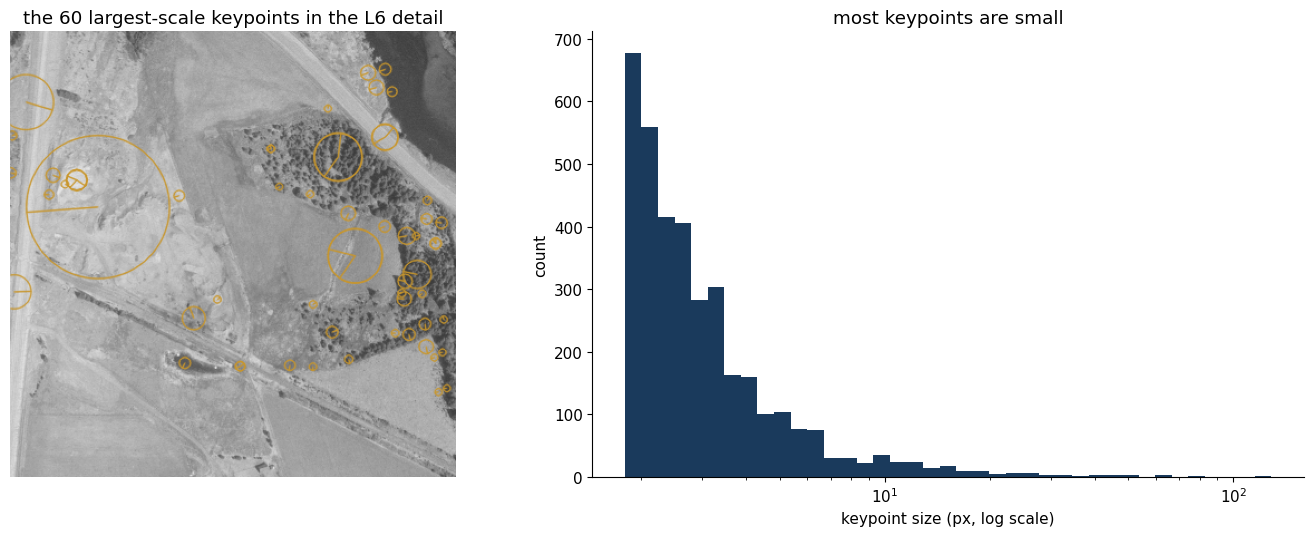

3,580 keypoints in 209 ms;  descriptor array (3580, 128), float32, 1.83 MB
median size 2.6 px;  87% are smaller than 5 px


In [ ]:
t0 = time.perf_counter()
kps, des = sift.detectAndCompute(img, None)
t_sift = time.perf_counter() - t0

sub = (slice(0, 400), slice(400, 800))             # the same detail used in L6
in_sub = [k for k in kps if k.pt[1] < 400 and k.pt[0] >= 400]
big = sorted(in_sub, key=lambda k: -k.size)[:60]
shifted = [cv2.KeyPoint(k.pt[0]-400, k.pt[1], k.size, k.angle) for k in big]
vis = cv2.drawKeypoints(cv2.cvtColor(img[sub], cv2.COLOR_GRAY2BGR), shifted, None,
                        color=(44, 150, 200), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

sizes = np.array([k.size for k in kps])
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1, 1.2]})
ax[0].imshow(vis[..., ::-1]); ax[0].set_title("the 60 largest-scale keypoints in the L6 detail"); ax[0].axis('off')
ax[1].hist(sizes, bins=np.geomspace(sizes.min(), sizes.max(), 40), color=NAVY)
ax[1].set_xscale('log'); ax[1].set_xlabel("keypoint size (px, log scale)"); ax[1].set_ylabel("count")
ax[1].set_title("most keypoints are small")
plt.tight_layout(); plt.show()

print(f"{len(kps):,} keypoints in {t_sift*1000:.0f} ms;  descriptor array {des.shape}, {des.dtype}, "
      f"{des.nbytes/1e6:.2f} MB")
print(f"median size {np.median(sizes):.1f} px;  {100*(sizes < 5).mean():.0f}% are smaller than 5 px")

Most keypoints are tiny — film grain and field texture at the finest scales. The large
ones sit on the woodlots and field boundaries you would pick by eye. Keep that
distribution in mind for section 11.

---
## 6 · Binary descriptors — BRIEF from scratch

SIFT is 128 floats = 512 bytes per keypoint, and comparing two costs 128 subtractions,
squares and adds. **BRIEF** (Calonder et al., 2010) asks a much cheaper question
256 times:

> *Is pixel $p$ darker than pixel $q$?*

Fix 256 random pixel pairs inside a smoothed 31×31 patch once, and each keypoint becomes
256 bits = **32 bytes**. Comparing two is an XOR and a population count.

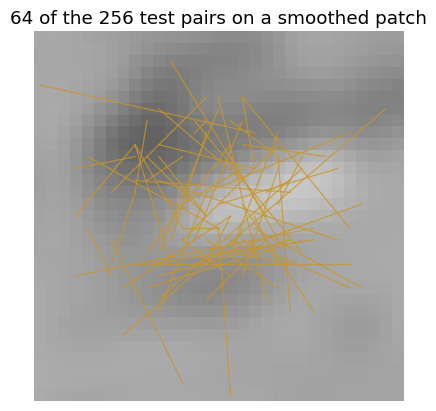

first keypoint : 0111000010111100010001100010101001001100101100101110110011111111 ...
second keypoint: 0111100001100011101001001100111001001111001010000011011100000001 ...
Hamming distance = 135 of 256 bits differ


In [ ]:
rng = np.random.default_rng(3950)
PAIRS = np.clip(np.round(rng.normal(0, 31/5, size=(256, 4))), -15, 15).astype(int)   # (x1, y1, x2, y2)

def brief(img, kps, pairs=PAIRS):
    # Plain BRIEF: 256 intensity comparisons on a Gaussian-smoothed image -> 32 bytes.
    sm = cv2.GaussianBlur(img, (0, 0), 2)
    out, keep = [], []
    for k in kps:
        x, y = map(int, map(round, k.pt))
        if 16 <= x < img.shape[1]-16 and 16 <= y < img.shape[0]-16:
            bits = sm[y + pairs[:, 1], x + pairs[:, 0]] < sm[y + pairs[:, 3], x + pairs[:, 2]]
            out.append(np.packbits(bits)); keep.append(k)
    return np.array(out, np.uint8), keep

kx, ky = map(int, map(round, strong[0].pt))
sm = cv2.GaussianBlur(img, (0, 0), 2)
fig, ax = plt.subplots(figsize=(4.8, 4.8))
ax.imshow(sm[ky-15:ky+16, kx-15:kx+16], cmap='gray', vmin=0, vmax=255, extent=[-15.5, 15.5, 15.5, -15.5])
for x1, y1, x2, y2 in PAIRS[:64]:
    ax.plot([x1, x2], [y1, y2], '-', color=GOLD, lw=0.9, alpha=0.8)
ax.set_title("64 of the 256 test pairs on a smoothed patch"); ax.axis('off'); plt.show()

d = brief(img, strong[:2])[0]
print("first keypoint :", ''.join(str(b) for b in np.unpackbits(d[0])[:64]), "...")
print("second keypoint:", ''.join(str(b) for b in np.unpackbits(d[1])[:64]), "...")
print(f"Hamming distance = {np.unpackbits(d[0] ^ d[1]).sum()} of 256 bits differ")

In [ ]:
# BRIEF has no orientation. Watch what happens as the second image rotates.
fast = cv2.FastFeatureDetector_create(threshold=25)
print(" angle   BRIEF correct")
brief_acc = []
for a in [0, 5, 10, 20, 30, 45]:
    im2, Ha, m2 = make_pair(img, angle=a, scale=1.0, gain=1.0, gamma=1.0, noise=0)
    b1, kb1 = brief(img, fast.detect(img, None))
    b2, kb2 = brief(im2, fast.detect(im2, m2))
    brief_acc.append(nn_accuracy(kb1, b1, kb2, b2, Ha, cv2.NORM_HAMMING))
    print(f"  {a:3d}°      {100*brief_acc[-1]:5.1f}%")

 angle   BRIEF correct


    0°      100.0%


    5°       94.3%


   10°       87.3%


   20°       32.8%


   30°        3.0%


   45°        0.2%


Excellent when the camera does not rotate — which is more common than you might think
(a drone on a fixed heading, a car dashcam, a microscope stage). Hopeless otherwise. ORB
fixes exactly that.

---
## 7 · ORB — Oriented FAST and Rotated BRIEF

ORB (Rublee et al., 2011) is the free, fast alternative that OpenCV built when SIFT was
still patented:

| Piece | What it does |
|---|---|
| **FAST** | A pixel is a corner if ≥ 9 contiguous pixels on a 16-pixel circle around it are all brighter or all darker. Just comparisons. |
| **Harris ranking** | FAST fires on edges too; keep the top $N$ by Harris response (L6). |
| **Pyramid** | Run it on 8 levels, each 1/1.2 the size — ORB's answer to scale. |
| **Intensity centroid** | Orientation $\theta = \operatorname{atan2}(m_{01}, m_{10})$ where $m_{pq} = \sum x^p y^q I(x,y)$ over the patch. |
| **Steered BRIEF** | Rotate the 256 test pairs by $\theta$ before comparing. The pairs are *learned* to be uncorrelated, not random. |

In [ ]:
def intensity_centroid_angle(img, kp, r=15):
    # ORB's orientation: direction from the patch centre to its intensity centroid.
    x, y = map(int, map(round, kp.pt))
    P = img[y-r:y+r+1, x-r:x+r+1].astype(np.float64)
    yy, xx = np.mgrid[-r:r+1, -r:r+1]
    disk = xx**2 + yy**2 <= r*r                  # ORB uses a circular patch
    m10, m01 = (xx * P * disk).sum(), (yy * P * disk).sum()
    return np.degrees(np.arctan2(m01, m10)) % 360, m10, m01

# Worked example: a 5x5 patch, bright in the lower-right.
toy = np.array([[0, 0,  0,  0,  0],
                [0, 0,  0,  0,  0],
                [0, 0, 10, 10, 10],
                [0, 0, 10, 10, 10],
                [0, 0, 10, 10, 10]], float)
yy, xx = np.mgrid[-2:3, -2:3]
m10, m01 = (xx*toy).sum(), (yy*toy).sum()
print(f"toy patch: m10 = {m10:.0f}, m01 = {m01:.0f}, theta = atan2(m01, m10) = "
      f"{np.degrees(np.arctan2(m01, m10)):.0f}°   (y points down, so 'down-right')")

kpo, dso = orb.detectAndCompute(img, None)
diffs = []
for k in kpo:
    if k.octave == 0 and 16 <= k.pt[0] < w-16 and 16 <= k.pt[1] < h-16:
        a, *_ = intensity_centroid_angle(img, k)
        diffs.append(abs((a - k.angle + 180) % 360 - 180))
print(f"\nour centroid angle vs OpenCV ORB (level-0 keypoints): median difference {np.median(diffs):.1f}°")
print(f"ORB: {len(kpo):,} keypoints, descriptor {dso.shape} {dso.dtype} = {dso.nbytes/len(kpo):.0f} bytes each")

toy patch: m10 = 90, m01 = 90, theta = atan2(m01, m10) = 45°   (y points down, so 'down-right')

our centroid angle vs OpenCV ORB (level-0 keypoints): median difference 1.5°
ORB: 2,922 keypoints, descriptor (2922, 32) uint8 = 32 bytes each


---
## 8 · Distance metrics

| Metric | Formula | Use with |
|---|---|---|
| **L2 (Euclidean)** | $\lVert a-b\rVert_2 = \sqrt{\sum (a_i-b_i)^2}$ | SIFT, any float descriptor |
| **L1 (Manhattan)** | $\sum \lvert a_i-b_i\rvert$ | float descriptors; less swayed by one big difference |
| **Cosine** | $1 - \dfrac{a\cdot b}{\lVert a\rVert\lVert b\rVert}$ | float descriptors |
| **Hamming** | $\operatorname{popcount}(a \oplus b)$ | BRIEF, ORB, any binary descriptor |

For unit-length vectors (SIFT after normalisation) L2 and cosine carry the *same*
information: $\lVert a-b\rVert^2 = 2 - 2\,a\cdot b$. So they rank neighbours identically.

In [ ]:
a, b = d1[0], d1[1]
an, bn = a/np.linalg.norm(a), b/np.linalg.norm(b)
print(f"two SIFT descriptors:  L2 = {np.linalg.norm(an-bn):.4f}   "
      f"sqrt(2 - 2 cos) = {np.sqrt(2 - 2*an@bn):.4f}   <- identical")

# Hamming by hand on one byte, then on a whole ORB descriptor
x, y = np.uint8(0b10110010), np.uint8(0b10011011)
print(f"\n    {x:08b}\nXOR {y:08b}\n  = {x ^ y:08b}   ->  Hamming distance = popcount = {bin(x ^ y).count('1')}")

# Speed: brute-force all-pairs distance, float L2 vs binary Hamming, same number of keypoints
N = 2000
F1, F2 = d1[:N], d2[:N]
B1, B2 = dso[:N], dso[:N][::-1].copy()
for name, (p, q, norm) in {"SIFT, L2      ": (F1, F2, cv2.NORM_L2),
                           "ORB, Hamming  ": (B1, B2, cv2.NORM_HAMMING)}.items():
    bf = cv2.BFMatcher(norm); bf.match(p, q)          # warm up
    t0 = time.perf_counter()
    for _ in range(5): bf.match(p, q)
    dt = (time.perf_counter() - t0) / 5
    print(f"{name} {N}x{N} brute force: {dt*1000:6.1f} ms   memory {p.nbytes/1e3:6.0f} kB")

two SIFT descriptors:  L2 = 1.0953   sqrt(2 - 2 cos) = 1.0953   <- identical

    10110010
XOR 10011011
  = 00101001   ->  Hamming distance = popcount = 3


SIFT, L2       2000x2000 brute force:   39.9 ms   memory   1024 kB
ORB, Hamming   2000x2000 brute force:   14.0 ms   memory     64 kB


### 8.1 — The slide self-check, done for you

One 8-bit query against three stored 8-bit descriptors, twice. Work out the Hamming
distances and the ratio-test decision ($r = 0.8$) by hand first, then run this cell.

In [ ]:
stored = {"a": 0b10110011, "b": 0b00110110, "c": 0b11001001}
queries = {"q": 0b10110110, "p": 0b01011100}

for qn, qv in queries.items():
    d = {k: bin(qv ^ v).count("1") for k, v in stored.items()}
    (n1, d1_), (n2, d2_) = sorted(d.items(), key=lambda t: t[1])[:2]
    r = d1_ / d2_
    print(f"query {qn} = {qv:08b}:  " + "   ".join(f"H({qn},{k}) = {v}" for k, v in d.items()))
    print(f"    nearest {n1} ({d1_}), runner-up {n2} ({d2_}),  ratio = {r:.2f}  ->  "
          f"{'ACCEPT ' + qn + '->' + n1 if r < 0.8 else 'REJECT (ambiguous)'}\n")

query q = 10110110:  H(q,a) = 2   H(q,b) = 1   H(q,c) = 7
    nearest b (1), runner-up a (2),  ratio = 0.50  ->  ACCEPT q->b

query p = 01011100:  H(p,a) = 7   H(p,b) = 4   H(p,c) = 4
    nearest b (4), runner-up c (4),  ratio = 1.00  ->  REJECT (ambiguous)



### 8.2 — Wrong metric, silently wrong answer

`BFMatcher()` defaults to L2. Hand it ORB's `uint8` bytes and it will happily treat each
byte as a number from 0 to 255 — so flipping the top bit costs 128 and flipping the bottom
bit costs 1. It runs, it returns matches, and the matches are worse.

In [ ]:
k2o, d2o = orb.detectAndCompute(img2, mask2)
for name, norm in {"NORM_HAMMING (right)": cv2.NORM_HAMMING, "NORM_L2 (wrong)": cv2.NORM_L2}.items():
    good = ratio_matches(dso, d2o, norm)
    ok = is_correct(kpo, k2o, good, H)
    print(f"{name:22} {len(good):5d} kept   {100*ok.mean():5.1f}% correct   {ok.sum():5d} right")

NORM_HAMMING (right)    1180 kept    96.0% correct    1133 right


NORM_L2 (wrong)          584 kept    92.5% correct     540 right


---
## 9 · Matching strategies and the ratio test

Given descriptors in two images, which pairs do we keep?

1. **Nearest neighbour** — every keypoint gets its closest partner. Many keypoints *have*
   no partner (occluded, out of frame, not re-detected) so this must be wrong a lot.
2. **Distance threshold** — keep pairs with $d_1 < t$. But a good $t$ depends on the
   image, the descriptor and the region.
3. **Cross-check** — keep $a \to b$ only if $b$'s nearest neighbour is also $a$.
4. **Ratio test** (Lowe 2004) — keep $a \to b$ only if $d_1 / d_2 < r$, where $d_2$ is the
   distance to the *second*-nearest. A distinctive match is much closer than the runner-up;
   an ambiguous one is not.

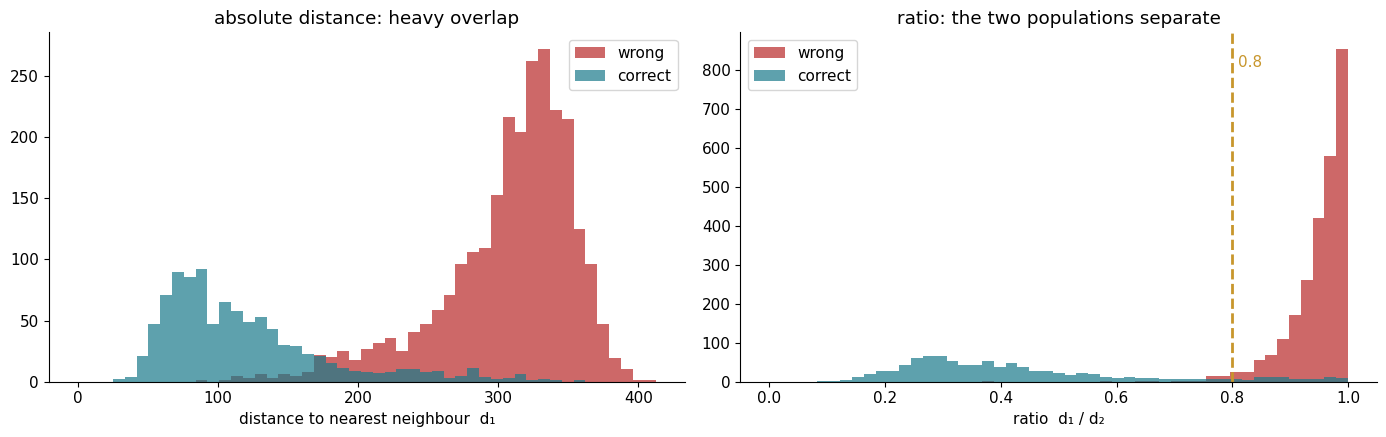

nearest neighbour for every keypoint: 3,580 matches, 27% correct


In [ ]:
knn = cv2.BFMatcher(cv2.NORM_L2).knnMatch(d1, d2, k=2)
nn  = [m for m, n in knn]
d_1 = np.array([m.distance for m, n in knn])
d_2 = np.array([n.distance for m, n in knn])
ratio = d_1 / d_2
right = is_correct(k1, k2, nn, H)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
bins = np.linspace(0, d_1.max(), 50)
ax[0].hist(d_1[~right], bins, color=RED, alpha=0.7, label="wrong")
ax[0].hist(d_1[right],  bins, color=TEAL, alpha=0.7, label="correct")
ax[0].set_xlabel("distance to nearest neighbour  d₁"); ax[0].set_title("absolute distance: heavy overlap"); ax[0].legend()
bins = np.linspace(0, 1, 50)
ax[1].hist(ratio[~right], bins, color=RED, alpha=0.7, label="wrong")
ax[1].hist(ratio[right],  bins, color=TEAL, alpha=0.7, label="correct")
ax[1].axvline(0.8, color=GOLD, ls='--', lw=2); ax[1].text(0.81, ax[1].get_ylim()[1]*0.9, "0.8", color=GOLD)
ax[1].set_xlabel("ratio  d₁ / d₂"); ax[1].set_title("ratio: the two populations separate"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"nearest neighbour for every keypoint: {len(nn):,} matches, {100*right.mean():.0f}% correct")

In [ ]:
def report(label, keep):
    keep = np.asarray(keep)
    print(f"{label:30} kept {keep.sum():5,}   precision {100*right[keep].mean():5.1f}%   correct {right[keep].sum():5,}")

report("nearest neighbour only", np.ones_like(right))
for r in (0.6, 0.7, 0.8, 0.9):
    report(f"ratio test  r = {r}", ratio < r)

cc = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True).match(d1, d2)
cc_ok = is_correct(k1, k2, cc, H)
print(f"{'cross-check':30} kept {len(cc):5,}   precision {100*cc_ok.mean():5.1f}%   correct {cc_ok.sum():5,}")

keep = ratio < 0.8
print(f"\nat r = 0.8: removed {100*(~keep & ~right).sum()/(~right).sum():.0f}% of the wrong matches, "
      f"lost {100*(~keep & right).sum()/right.sum():.0f}% of the correct ones")
n08 = int(keep.sum())
best_abs = np.zeros_like(right); best_abs[np.argsort(d_1)[:n08]] = True
report(f"best {n08} by absolute d₁", best_abs)

nearest neighbour only         kept 3,580   precision  27.0%   correct   965
ratio test  r = 0.6            kept   804   precision  99.8%   correct   802
ratio test  r = 0.7            kept   853   precision  99.2%   correct   846
ratio test  r = 0.8            kept   931   precision  94.8%   correct   883
ratio test  r = 0.9            kept 1,266   precision  73.2%   correct   927
cross-check                    kept 1,068   precision  85.6%   correct   914

at r = 0.8: removed 98% of the wrong matches, lost 8% of the correct ones
best 931 by absolute d₁        kept   931   precision  91.1%   correct   848


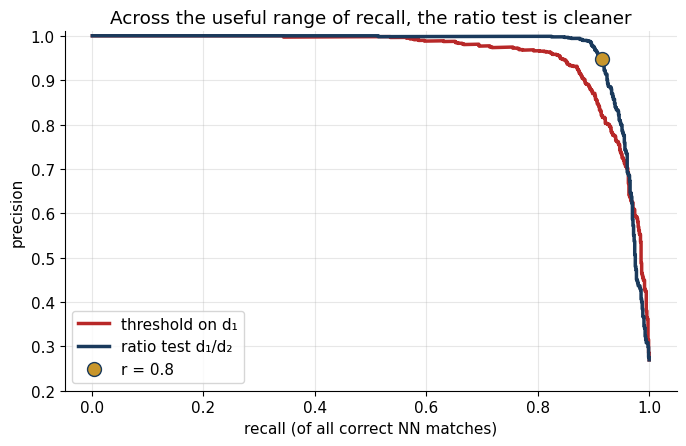

In [ ]:
# Precision-recall: sweep the threshold on d1 and on d1/d2
def pr(score):
    order = np.argsort(score)
    tp = np.cumsum(right[order])
    return tp / right.sum(), tp / np.arange(1, len(order) + 1)

plt.figure(figsize=(7, 4.6))
for s, lab, col in [(d_1, "threshold on d₁", RED), (ratio, "ratio test d₁/d₂", NAVY)]:
    rec, prec = pr(s); plt.plot(rec, prec, color=col, lw=2.5, label=lab)
rec, prec = pr(ratio); i = (ratio < 0.8).sum() - 1
plt.plot(rec[i], prec[i], 'o', color=GOLD, ms=10, mec=NAVY, label="r = 0.8")
plt.xlabel("recall (of all correct NN matches)"); plt.ylabel("precision")
plt.ylim(0.2, 1.01); plt.grid(alpha=0.3); plt.legend(loc="lower left")
plt.title("Across the useful range of recall, the ratio test is cleaner")
plt.tight_layout(); plt.show()

The ratio test does not need to know what a "good" distance is for this image. It only
asks whether the best answer is clearly better than the next best — a question that
transfers between images, descriptors and datasets. Lowe's 0.8 threw away 90% of the
false matches while losing less than 5% of the correct ones on his data; check the
numbers above against that.

**Cross-check** is a reasonable alternative and needs no parameter, but it cannot use
$k=2$ at the same time in OpenCV's `BFMatcher`. AL5 on Friday compares the two with FLANN.

---
## 10 · SIFT vs ORB, head to head

Same test pair, both with the ratio test at 0.8.

In [ ]:
rows = []
for name, det, norm in [("SIFT", cv2.SIFT_create(), cv2.NORM_L2),
                        ("ORB",  cv2.ORB_create(nfeatures=3000), cv2.NORM_HAMMING)]:
    det.detectAndCompute(img, None)                  # warm up
    t0 = time.perf_counter()
    ka, da = det.detectAndCompute(img, None)
    kb, db = det.detectAndCompute(img2, mask2)
    t_det = (time.perf_counter() - t0) / 2
    t0 = time.perf_counter()
    good = ratio_matches(da, db, norm)
    t_match = time.perf_counter() - t0
    ok = is_correct(ka, kb, good, H)
    rows.append((name, len(ka), da.shape[1], da.dtype, da.nbytes/len(ka),
                 1000*t_det, 1000*t_match, len(good), 100*ok.mean(), ok.sum()))
    if name == "SIFT": sift_pair = (ka, kb, good, ok)

print(f"{'':5} {'kps':>6} {'dims':>5} {'dtype':>8} {'bytes':>6} {'detect+desc':>12} {'match':>8} "
      f"{'kept':>6} {'precision':>10} {'right':>6}")
for r in rows:
    print(f"{r[0]:5} {r[1]:6,} {r[2]:5} {str(r[3]):>8} {r[4]:6.0f} {r[5]:9.0f} ms {r[6]:5.0f} ms "
          f"{r[7]:6,} {r[8]:9.1f}% {r[9]:6,}")
print(f"\nORB describes an image {rows[0][5]/rows[1][5]:.0f}x faster here, with descriptors "
      f"{rows[0][4]/rows[1][4]:.0f}x smaller.")

         kps  dims    dtype  bytes  detect+desc    match   kept  precision  right
SIFT   3,580   128  float32    512       179 ms    53 ms    931      94.8%    883
ORB    2,922    32    uint8     32        12 ms    37 ms  1,180      96.0%  1,133

ORB describes an image 15x faster here, with descriptors 16x smaller.


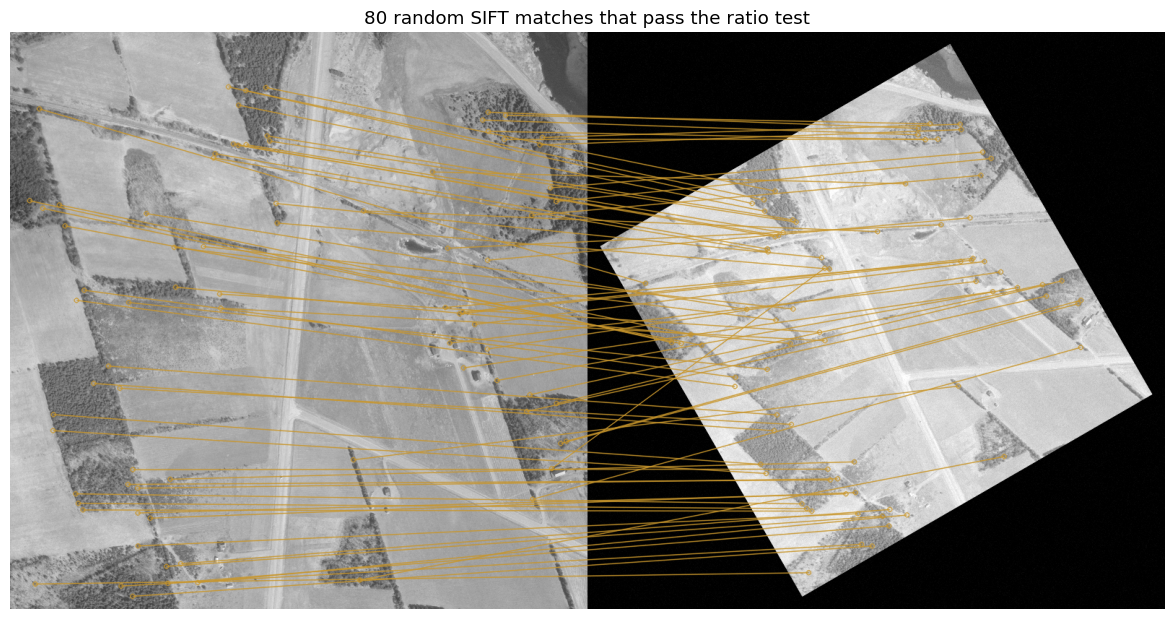

In [ ]:
ka, kb, good, ok = sift_pair
sel = np.random.default_rng(1).choice(len(good), 80, replace=False)
vis = cv2.drawMatches(img, ka, img2, kb, [good[i] for i in sel], None,
                      matchColor=(44, 150, 200), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(15, 7.5)); plt.imshow(vis[..., ::-1]); plt.axis('off')
plt.title("80 random SIFT matches that pass the ratio test"); plt.show()

Timings depend on your machine — Colab's CPU is slower than a laptop — but the *ratio*
is stable. On this pair ORB is at least as accurate as SIFT. SIFT's usual advantage shows up
with large scale changes and blur (Try-at-home **B**); ORB is the one you can run on video,
or on every tile of a 30,000 × 30,000 px mosaic.

---
## 11 · Across a decade — 1958 vs 1968

Everything so far used a warped copy of the *same* photograph. Now try two real
photographs of the same fields, ten years apart. For ground truth we align the two clips
with a dense intensity-based method (`cv2.findTransformECC` on heavily blurred copies —
not something we cover; treat it as a given). The checkerboard below shows the alignment
is good to a few pixels: roads and hedgerows run straight across the tile boundaries.

ECC correlation 0.592;  W =
[[ 1.0231 -0.0139 -1.7498]
 [-0.0148  1.0286 13.3731]]


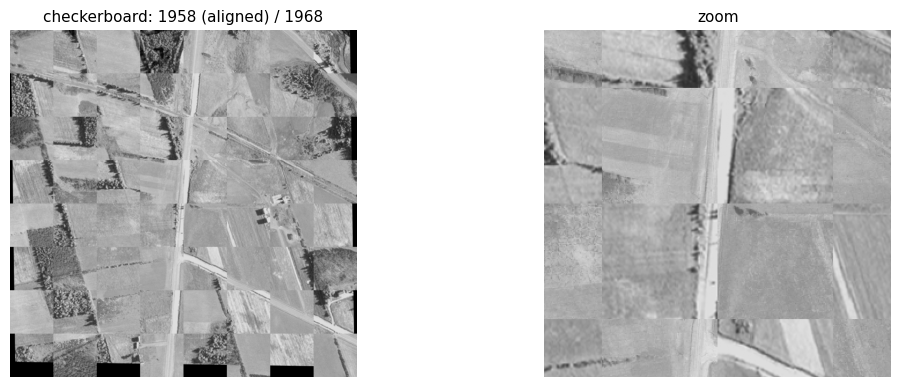

In [ ]:
A, B = aerial[1958], aerial[1968]

def ecc_align(a, b):
    # Affine W with a(W [x;1]) ≈ b(x), coarse to fine. Used only as ground truth.
    W = np.eye(2, 3, dtype=np.float32)
    crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 500, 1e-6)
    for s in (8, 4, 2):
        fa = cv2.GaussianBlur(a.astype(np.float32), (0, 0), s)
        fb = cv2.GaussianBlur(b.astype(np.float32), (0, 0), s)
        cc, W = cv2.findTransformECC(fb, fa, W, cv2.MOTION_AFFINE, crit, None, 5)
    return W.astype(np.float64), cc

W, cc = ecc_align(A, B)
print(f"ECC correlation {cc:.3f};  W =\n{np.round(W, 4)}")

A_in_B = cv2.warpAffine(A, W, (side, side), flags=cv2.INTER_LINEAR | cv2.WARP_INVERSE_MAP)
cb = B.copy(); T = 100
for i in range(side // T):
    for j in range(side // T):
        if (i + j) % 2: cb[i*T:(i+1)*T, j*T:(j+1)*T] = A_in_B[i*T:(i+1)*T, j*T:(j+1)*T]
show([cb, cb[250:550, 250:550]], ["checkerboard: 1958 (aligned) / 1968", "zoom"], figw=12)

def correct_era(kA, kB, matches, tol=8):
    pa = np.float32([kA[m.queryIdx].pt for m in matches])
    pb = np.float32([kB[m.trainIdx].pt for m in matches])
    return np.linalg.norm(np.c_[pb, np.ones(len(pb))] @ W.T - pa, axis=1) < tol

In [ ]:
print(f"{'':5} {'kps 1958':>9} {'kps 1968':>9} {'ratio<0.8 kept':>15} {'correct':>8}")
era = {}
for name, det, norm in [("SIFT", cv2.SIFT_create(), cv2.NORM_L2),
                        ("ORB",  cv2.ORB_create(nfeatures=3000), cv2.NORM_HAMMING)]:
    kA, dA = det.detectAndCompute(A, None)
    kB, dB = det.detectAndCompute(B, None)
    good = ratio_matches(dA, dB, norm)
    ok = correct_era(kA, kB, good)
    era[name] = (kA, dA, kB, dB, good, ok)
    print(f"{name:5} {len(kA):9,} {len(kB):9,} {len(good):15,} {ok.sum():8,}")

       kps 1958  kps 1968  ratio<0.8 kept  correct


SIFT     10,308     3,580             133        1
ORB       3,000     2,922              41        3


591 keypoint pairs on the same ground spot (< 2 px) at a similar scale.
Rank of the true partner among 10,308 candidates:  median 3,712,  ranked #1 for 0,  top-10 for 5
(a random guess would have median rank ≈ 5,154)


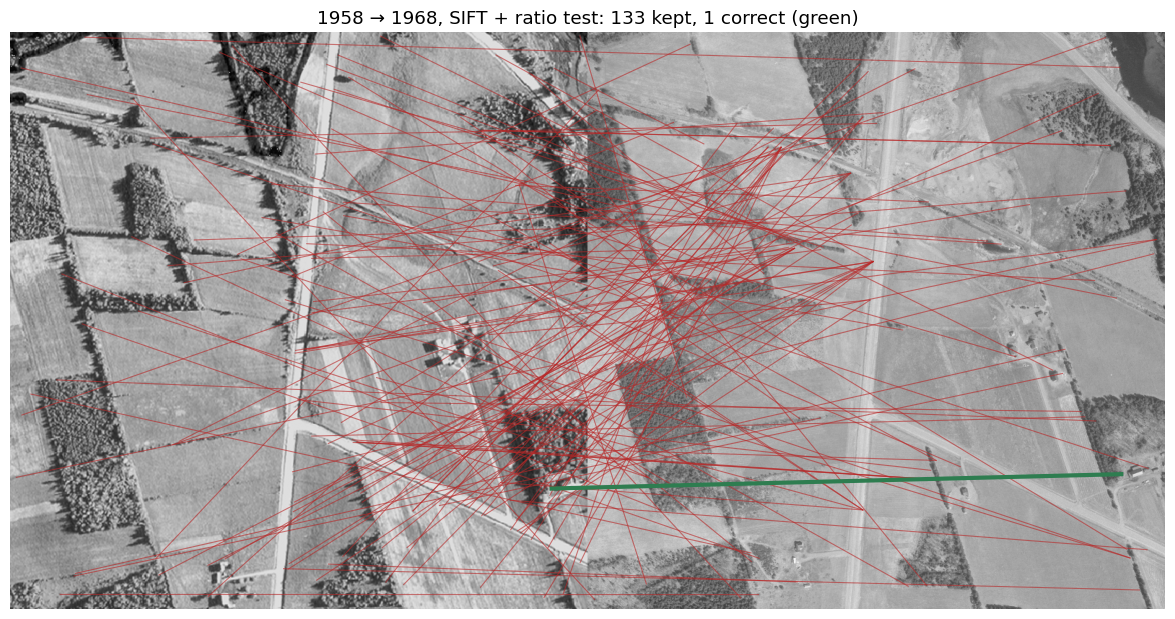

In [ ]:
# Is it the detector or the descriptor? Find keypoint pairs that land on the same spot
# at a similar scale — the detector did its job — and ask where the true partner ranks.
from scipy.spatial import cKDTree
kA, dA, kB, dB, good, ok = era["SIFT"]
PA = np.float32([k.pt for k in kA])
PB_in_A = np.c_[np.float32([k.pt for k in kB]), np.ones(len(kB))] @ W.T
dist, idx = cKDTree(PA).query(PB_in_A)
pairs = [(j, i) for j, (dd, i) in enumerate(zip(dist, idx))
         if dd < 2 and abs(np.log2(kB[j].size / kA[i].size)) < 0.5]

ranks = np.array([(np.linalg.norm(dA - dB[j], axis=1) < np.linalg.norm(dA[i] - dB[j])).sum() + 1
                  for j, i in pairs])
print(f"{len(pairs)} keypoint pairs on the same ground spot (< 2 px) at a similar scale.")
print(f"Rank of the true partner among {len(kA):,} candidates:  median {np.median(ranks):,.0f},  "
      f"ranked #1 for {(ranks == 1).sum()},  top-10 for {(ranks <= 10).sum()}")
print(f"(a random guess would have median rank ≈ {len(kA)//2:,})")

canvas = np.hstack([A, B])
plt.figure(figsize=(15, 7.5)); plt.imshow(canvas, cmap='gray', vmin=0, vmax=255)
for m, o in sorted(zip(good, ok), key=lambda t: t[1]):      # draw correct ones last, on top
    (xa, ya), (xb, yb) = kA[m.queryIdx].pt, kB[m.trainIdx].pt
    plt.plot([xa, xb + side], [ya, yb], '-', color=GREEN if o else RED,
             lw=3 if o else 0.8, alpha=1 if o else 0.6)
plt.axis('off')
plt.title(f"1958 → 1968, SIFT + ratio test: {len(good)} kept, {ok.sum()} correct (green)"); plt.show()

**This is the most important cell in the notebook.** The same descriptor that was
right 95% of the time on a synthetic warp is barely better than guessing here. The detector
is not the main problem — hundreds of keypoint pairs sit on the same ground spot at a
similar scale in both years. The *descriptors* of those points simply do not resemble each other.

Why? Ten years of crop rotation, a different season, different film and scanner, a
different sun angle flipping which side of every hedgerow is in shadow. SIFT is
invariant to the changes it was designed for — rotation, scale, linear lighting — and to
none of these.

This matters for your projects (mosaics, oblique localisation, anything multi-temporal):
**test on your own pair before you trust a pipeline**. L8's RANSAC can rescue a match set
that is 50% wrong; it cannot rescue one that is 99% wrong. L19 comes back to what does work.

---
## ✏️ Try at home

Not graded. **A** and **B** are a good place to focus.

### A — Where does 0.8 come from?
Using the test pair from section 9, plot precision and number of correct matches
against the ratio threshold from 0.5 to 1.0. Where is the "knee"? Repeat with ORB.
Is the best threshold the same for both descriptors?

### B — How much rotation does ORB really tolerate?
Section 1 swept rotation with scale fixed at 1. Sweep *scale* from 0.3 to 1.0 at 0°
rotation instead, for SIFT and ORB. ORB's pyramid has 8 levels at a factor of 1.2 —
predict where ORB should start to fail before you run it.

### C — Put trilinear interpolation back
Modify `my_sift` so each gradient vote is shared between the two nearest orientation
bins (linear in angle). Does the number of matches kept in section 3 rise towards
OpenCV's? Then share votes between neighbouring cells too.

### D — RootSIFT
Arandjelović & Zisserman (2012) replace each SIFT vector by $\sqrt{d / \lVert d\rVert_1}$
and then use L2 as usual. It is three lines of NumPy. Does it change the section 9 or the
section 11 results?

### E — Can anything match across the decade?
Try one idea on the 1958/1968 pair and measure it with `correct_era`: CLAHE before
detection; only large keypoints (`kp.size > 10`); downsampling both images first;
restricting each keypoint's candidates to within 30 px of where `W` says it should be
(this is cheating — but it tells you whether the descriptor has *any* signal left).